In [2]:
import os
os.getcwd()
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data/")
DATA_15MIN = DATA_DIR / "15min"
WEATHER_1H = DATA_DIR / "weather_data_hourly"
WEATHER_OVERVIEW = DATA_DIR / "weather_data_overview"

weather_var = pd.read_csv(WEATHER_OVERVIEW / "weather_variables.csv", sep=';')
weather_var

,VariableName,ParameterGroup,Resolution,Unit,Description
0,Temperature_avg_hourly,temperature,hourly,degrees Celsius,Air temperature 2 m above ground - hourly average
1,Temperature_max_daily,temperature,daily,degrees Celsius,Air temperature 2 m above ground - daily maximum
2,Temperature_min_daily,temperature,daily,degrees Celsius,Air temperature 2 m above ground - daily minimum
3,Temperature_avg_daily,temperature,daily,degrees Celsius,Air temperature 2 m above ground - daily average
4,HeatingDegree_SIA_daily,temperature,daily,degrees Celsius,Heating degree number 12/20 (SIA: heating degr...
5,HeatingDegree_US_daily,temperature,daily,degrees Celsius,Heating degree number (HDD: Heating Degree Day...
6,CoolingDegree_US_daily,temperature,daily,degrees Celsius,"Cooling degree number (CDD:Cooling Degree Day,..."
7,DewPoint_hourly,temperature,hourly,degrees Celsius,Dew point 2 m above ground - hourly instantane...
8,Humidity_avg_hourly,humidity,hourly,percentage,Relative humidity 2 m above ground - hourly av...
9,Humidity_avg_daily,humidity,daily,percentage,Relative humidity 2 m above ground - daily ave...


In [ ]:
META_DIR = DATA_DIR / "smart_meter_meta_data"

# Households flagged as PV owners (the flag is True / False / empty)
households = pd.read_csv(META_DIR / "households.csv", sep=";")
pv_ids = households.loc[households["Installation_HasPVSystem"] == True, "Household_ID"]
pv_files = [DATA_15MIN / f"{hid}.csv" for hid in pv_ids]

# For each PV file: does it have Total and HeatPump readings, and for what share of rows?
rows = []
for f in pv_files:
    df = pd.read_csv(f, sep=";", usecols=["kWh_received_Total", "kWh_received_HeatPump"])
    rows.append({
        "Household_ID": int(f.stem),
        "file": f.name,
        "n_rows": len(df),
        "Total_share": df["kWh_received_Total"].notna().mean(),
        "HeatPump_share": df["kWh_received_HeatPump"].notna().mean(),
    })
pv_summary = pd.DataFrame(rows)
pv_summary["has_Total"] = pv_summary["Total_share"] > 0
pv_summary["has_HeatPump"] = pv_summary["HeatPump_share"] > 0
pv_summary["has_both"] = pv_summary["has_Total"] & pv_summary["has_HeatPump"]

print(f"{len(pv_files)} PV households")
print(pv_summary[["has_Total", "has_HeatPump", "has_both"]].sum().to_string())
pv_summary

131 PV households
has_Total       131
has_HeatPump      0
has_both          0


,Household_ID,file,n_rows,Total_share,HeatPump_share,has_Total,has_HeatPump,has_both
0,120701,120701.csv,54912,1.0,0.0,True,False,False
1,1078861,1078861.csv,38304,1.0,0.0,True,False,False
2,190821,190821.csv,123936,1.0,0.0,True,False,False
3,1191127,1191127.csv,28320,1.0,0.0,True,False,False
4,109711,109711.csv,68160,1.0,0.0,True,False,False
...,...,...,...,...,...,...,...,...
126,8212283,8212283.csv,79392,1.0,0.0,True,False,False
127,8611772,8611772.csv,68256,1.0,0.0,True,False,False
128,8877761,8877761.csv,62784,1.0,0.0,True,False,False
129,8985109,8985109.csv,36000,1.0,0.0,True,False,False


In [15]:
meta_data = pd.read_csv(META_DIR / "meta_data.csv", sep=";")

print(meta_data.columns.tolist())

['Household_ID', 'Survey_Building_Type', 'Survey_Building_LivingArea', 'Survey_Building_Residents', 'Survey_HeatPump_Installation_Type', 'Survey_HeatDistribution_System_FloorHeating', 'Survey_HeatDistribution_System_Radiator', 'Survey_DHW_Production_ByHeatPump', 'Survey_DHW_Production_ByElectricWaterHeater', 'Survey_DHW_Production_BySolar', 'Survey_Installation_HasDryer', 'Survey_Installation_HasFreezer', 'Survey_Installation_HasElectricVehicle']


In [16]:
for i, col in enumerate(meta_data.columns):
    print(f"{i}: {col}")

0: Household_ID
1: Survey_Building_Type
2: Survey_Building_LivingArea
3: Survey_Building_Residents
4: Survey_HeatPump_Installation_Type
5: Survey_HeatDistribution_System_FloorHeating
6: Survey_HeatDistribution_System_Radiator
7: Survey_DHW_Production_ByHeatPump
8: Survey_DHW_Production_ByElectricWaterHeater
9: Survey_DHW_Production_BySolar
10: Survey_Installation_HasDryer
11: Survey_Installation_HasFreezer
12: Survey_Installation_HasElectricVehicle


In [42]:
# Find all instance that are without metadata and without a full year of data

household_id_meta_data = meta_data["Household_ID"].astype(str)
print(f"Lenght {len(household_id_meta_data)}")

Lenght 393


In [20]:
smart_data_overview = pd.read_csv(META_DIR / "smart_meter_data_15min_overview.csv", sep=";")
smart_data_overview.head()

,Household_ID,SMD_15min_TimeAvailable_EarliestTimestamp,SMD_15min_TimeAvailable_LatestTimestamp,SMD_15min_TimeAvailable_NumberDays,SMD_15min_TimeAvailable_DaysBeforeVisit,SMD_15min_TimeAvailable_DaysAfterVisit,SMD_15min_MeasurementsAvailable_Total,SMD_15min_MeasurementsAvailable_HeatPump,SMD_15min_MeasurementsAvailable_Other
0,100120,2021-11-27 00:00:00+00:00,2024-02-27 23:45:00+00:00,790,713,76,True,False,False
1,103721,2021-04-23 00:00:00+00:00,2024-02-27 23:45:00+00:00,1039,641,397,True,False,False
2,104118,2022-05-03 00:00:00+00:00,2023-08-02 23:45:00+00:00,456,456,0,True,False,False
3,105714,2022-06-08 00:00:00+00:00,2024-02-27 23:45:00+00:00,628,543,84,True,False,False
4,105807,2020-10-01 00:00:00+00:00,2024-02-27 23:45:00+00:00,1241,460,780,True,False,False


In [40]:
# Convert timestamps to datetime
smart_data_overview["earliest"] = pd.to_datetime(
    smart_data_overview["SMD_15min_TimeAvailable_EarliestTimestamp"]
)

smart_data_overview["latest"] = pd.to_datetime(
    smart_data_overview["SMD_15min_TimeAvailable_LatestTimestamp"]
)

# Calculate duration
smart_data_overview["duration"] = (
    smart_data_overview["latest"] - smart_data_overview["earliest"]
)

# Duration in days
smart_data_overview["duration_days"] = (
    smart_data_overview["duration"].dt.total_seconds() / (24 * 3600)
)

more_than_one_year = smart_data_overview[
    smart_data_overview["duration_days"] > 365
].copy()


more_than_one_year[
    [
        "Household_ID",
        "SMD_15min_TimeAvailable_EarliestTimestamp",
        "SMD_15min_TimeAvailable_LatestTimestamp",
        "duration_days"
    ]
].sort_values("duration_days")

more_than_one_year_householdID = more_than_one_year['Household_ID']
print(f"More than one year of data: {len(more_than_one_year_householdID)} households")

More than one year of data: 396 households


In [48]:
household_id_meta_data = (
    household_id_meta_data
    .astype(str)
    .str.strip()
)

more_than_one_year_householdID = (
    more_than_one_year_householdID
    .astype(str)
    .str.strip()
)

valid_household_ids = (
    set(more_than_one_year_householdID)
    .intersection(set(household_id_meta_data))
)

print(f"Number of valid household IDs: {len(valid_household_ids)}")
print(valid_household_ids)

Number of valid household IDs: 379
{'708499', '101797', '121887', '1101186', '1017510', '1158778', '841087', '1007079', '7286748', '8087988', '112122', '716890', '611610', '103721', '382698', '105807', '688310', '808112', '7069411', '728210', '821088', '116121', '1041141', '103119', '121728', '114791', '851058', '778721', '120741', '461226', '1081057', '971044', '461158', '118708', '106102', '1193858', '1101068', '6577811', '856765', '110411', '1199104', '851017', '788488', '310610', '7906883', '108511', '9970781', '7846661', '111901', '119498', '121046', '6512274', '1065698', '4710670', '9889190', '112691', '796869', '7771161', '841184', '103991', '7747482', '847678', '109677', '801209', '1141141', '6808461', '6981151', '7474976', '8111796', '106109', '691171', '111651', '1075697', '1228100', '104118', '1214111', '105210', '9889114', '3699704', '106310', '1141047', '9711086', '1141091', '654611', '721077', '680861', '838351', '1019970', '1228011', '1147810', '908510', '688411', '67689

In [55]:
# Test if all valid household IDs are in the households df and have no missing datapoints
# Make sure the ID types match
household_ids = set(households["Household_ID"].astype(str).str.strip())
valid_ids = set(map(str, valid_household_ids))


# IDs from valid set that are missing from households
missing_ids = valid_ids - household_ids

# IDs from households that are not in the valid set
extra_ids = household_ids - valid_ids

print("Valid IDs:", len(valid_ids))
print("Households IDs:", len(household_ids))
print("Missing from households:", len(missing_ids))
# print("Extra in households:", len(extra_ids))

print("\nMissing IDs:")
print(sorted(missing_ids))

Valid IDs: 379
Households IDs: 410
Missing from households: 0

Missing IDs:
[]


In [56]:
from pathlib import Path
import pandas as pd

DATA_15MIN = DATA_DIR / "15min"

results = []

# valid_household_ids is already a set
valid_ids = set(map(str, valid_household_ids))

for file in DATA_15MIN.glob("*.csv"):

    # Household ID comes from filename
    household_id = file.stem.strip()

    # Only process households that are in valid_household_ids
    if household_id not in valid_ids:
        continue

    # Read timestamp only
    df = pd.read_csv(
        file,
        sep=";",
        usecols=["Timestamp"]
    )

    # Convert timestamp
    df["Timestamp"] = pd.to_datetime(
        df["Timestamp"],
        utc=True,
        errors="coerce"
    )

    # Remove missing timestamps
    timestamps = df["Timestamp"].dropna()

    if timestamps.empty:
        continue

    # Earliest and latest timestamp
    earliest = timestamps.min()
    latest = timestamps.max()

    # Duration
    duration = latest - earliest
    duration_days = duration.total_seconds() / (24 * 60 * 60)

    results.append({
        "Household_ID": household_id,
        "EarliestTimestamp": earliest,
        "LatestTimestamp": latest,
        "Duration_days": duration_days,
        "Duration_years": duration_days / 365.25
    })

# Create overview
timestamp_overview = pd.DataFrame(results)

# Households with at least one year
more_than_one_year = timestamp_overview[
    timestamp_overview["Duration_days"] >= 365.25
].copy()

# Households with less than one year
less_than_one_year = timestamp_overview[
    timestamp_overview["Duration_days"] < 365.25
].copy()

print("Valid household IDs:", len(valid_ids))
print("Valid households found in 15min folder:", len(timestamp_overview))
print("With >= 1 year:", len(more_than_one_year))
print("With < 1 year:", len(less_than_one_year))

Valid household IDs: 379
Valid households found in 15min folder: 379
With >= 1 year: 379
With < 1 year: 0


In [78]:
print(len(valid_household_ids))
valid_ids

379


{'100105',
 '1001121',
 '1001188',
 '100120',
 '1001228',
 '1006811',
 '1007079',
 '1009851',
 '1011091',
 '1015877',
 '1017510',
 '101797',
 '1019970',
 '1020729',
 '102106',
 '102119',
 '102310',
 '10266',
 '103119',
 '103721',
 '103724',
 '1037311',
 '1037610',
 '1038167',
 '103991',
 '1041141',
 '104118',
 '105113',
 '105210',
 '105461',
 '1056907',
 '105697',
 '105714',
 '1057211',
 '105807',
 '105900',
 '106100',
 '1061006',
 '106102',
 '106109',
 '1061168',
 '1061228',
 '106310',
 '1065698',
 '1066796',
 '106691',
 '106791',
 '106841',
 '1071058',
 '1073767',
 '107461',
 '1075697',
 '1078861',
 '1079731',
 '108100',
 '1081057',
 '108511',
 '108757',
 '108798',
 '1088228',
 '108849',
 '108927',
 '1090081',
 '109073',
 '109104',
 '109107',
 '109111',
 '1091217',
 '109677',
 '109711',
 '109879',
 '1101068',
 '1101151',
 '1101186',
 '1101758',
 '110411',
 '110766',
 '110810',
 '111119',
 '1111201',
 '1111228',
 '111387',
 '111651',
 '1118211',
 '111901',
 '1121071',
 '1121081',
 '11

## Find the household with PV

In [77]:
len(valid_household_ids)

379

In [79]:
valid_ids = set(map(str, valid_household_ids))

pv_valid_households = households[
    (households["Installation_HasPVSystem"] == True) &
    (households["Household_ID"].astype(str).str.strip().isin(valid_ids))
].copy()

print(len(pv_valid_households))

118


## How to find the PV generation target for training

In [80]:
pv_valid_households

,Household_ID,Group,Weather_ID,Installation_HasPVSystem,Protocols_Available,Protocols_HasMultipleVisits,Protocols_ReportIDs,MetaData_Available,SmartMeterData_Available_15min,SmartMeterData_Available_Daily,SmartMeterData_Available_Monthly
1,120701,treatment,Hg,True,True,False,[32],True,True,True,True
2,1078861,treatment,8jB,True,True,False,[138],True,True,True,True
3,190821,treatment,Hg,True,True,False,[139],True,True,True,True
14,109711,treatment,8jB,True,True,False,[190],True,True,True,True
17,826780,treatment,Hg,True,True,False,[204],True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...
388,8212283,control,8jB,True,False,False,NaN,True,True,True,True
395,8611772,control,8jB,True,False,False,NaN,True,True,True,True
399,8877761,control,Hg,True,False,False,NaN,True,True,True,True
403,8985109,control,HbsbG,True,False,False,NaN,True,True,True,True


## Weather Correlation Analysis


In [91]:
import glob 

weather_csv = glob.glob(str(WEATHER_1H / "*.csv"))
print(weather_csv)
csv_name = [Path(f).name for f in weather_csv]
print(csv_name)



['data/weather_data_hourly/8jB.csv', 'data/weather_data_hourly/Hg.csv', 'data/weather_data_hourly/wDD.csv', 'data/weather_data_hourly/z6I.csv', 'data/weather_data_hourly/HbsbG.csv', 'data/weather_data_hourly/ceOxS.csv', 'data/weather_data_hourly/sV3mR.csv', 'data/weather_data_hourly/MqO.csv']
['8jB.csv', 'Hg.csv', 'wDD.csv', 'z6I.csv', 'HbsbG.csv', 'ceOxS.csv', 'sV3mR.csv', 'MqO.csv']


In [94]:

from matplotlib.colors import ListedColormap

ID, TS = "Weather_ID", "Timestamp"
KEY_VARS = {"Temperature_avg_hourly", "Sunshine_duration_hourly"}   # main load/PV drivers
NO_FLATLINE = {"Precipitation_total_hourly", "Sunshine_duration_hourly", "WindSpeed_hourly"}  # long constant runs are normal

# 1) Load + timestamp integrity ------------------------------------------------
stations, ts_rows = {}, []
for f in sorted(WEATHER_1H.glob("*.csv")):
    raw = pd.read_csv(f, sep=";")
    raw[TS] = pd.to_datetime(raw[TS], utc=True, errors="coerce")
    sid = raw[ID].dropna().iloc[0]
    n_bad_ts = raw[TS].isna().sum()
    raw = raw.dropna(subset=[TS])
    n_dup = raw[TS].duplicated().sum()
    raw = raw.drop_duplicates(TS).set_index(TS).sort_index()
    grid = pd.date_range(raw.index.min(), raw.index.max(), freq="h")
    off_grid = (~raw.index.isin(grid)).sum()
    df = raw.drop(columns=ID).reindex(grid)                # missing rows -> NaN rows
    stations[sid] = df
    ts_rows.append(dict(station=sid, file=f.name, start=grid[0], end=grid[-1],
                        expected_rows=len(grid), present_rows=len(raw),
                        missing_rows=len(grid) - len(raw) + off_grid,
                        duplicate_ts=n_dup, unparseable_ts=n_bad_ts, off_grid_ts=off_grid))
ts_report = pd.DataFrame(ts_rows).set_index("station")
print("── Timestamp integrity ──")
display(ts_report)


── Timestamp integrity ──


,file,start,end,expected_rows,present_rows,missing_rows,duplicate_ts,unparseable_ts,off_grid_ts
station,,,,,,,,,
8jB,8jB.csv,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,45264,45264,0,0,0,0
HbsbG,HbsbG.csv,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,45264,45264,0,0,0,0
Hg,Hg.csv,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,45264,45264,0,0,0,0
MqO,MqO.csv,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,45264,45264,0,0,0,0
ceOxS,ceOxS.csv,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,45264,45264,0,0,0,0
sV3mR,sV3mR.csv,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,45264,45264,0,0,0,0
wDD,wDD.csv,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,45264,45264,0,0,0,0
z6I,z6I.csv,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,45264,45264,0,0,0,0


In [95]:

# 2) Gap statistics per station × variable ----------------------------------------
def gaps(mask: pd.Series) -> pd.DataFrame:
    """Contiguous NaN runs -> start, end, hours."""
    grp = mask.ne(mask.shift()).cumsum()[mask]
    if grp.empty:
        return pd.DataFrame(columns=["start", "end", "hours"])
    g = grp.groupby(grp).apply(lambda s: pd.Series({"start": s.index[0], "end": s.index[-1], "hours": len(s)}))
    return g.unstack() if isinstance(g.index, pd.MultiIndex) else g

def severity(pct, max_h):
    if pct == 0:                     return "none"
    if pct < 0.5 and max_h <= 3:     return "low"
    if pct < 2 and max_h <= 24:      return "moderate"
    if pct < 10 and max_h <= 24 * 7: return "high"
    return "severe"

rows, gap_list = [], []
for sid, df in stations.items():
    for c in df.columns:
        g = gaps(df[c].isna())
        h = g["hours"].astype(int) if len(g) else pd.Series(dtype=int)
        pct = df[c].isna().mean() * 100
        rows.append({"station": sid, "variable": c, "key_var": c in KEY_VARS,
                     "pct_missing": round(pct, 3), "missing_h": int(h.sum()), "n_gaps": len(h),
                     "max_gap_h": int(h.max()) if len(h) else 0,
                     "gaps_1h": (h == 1).sum(), "gaps_2-3h": h.between(2, 3).sum(),
                     "gaps_4-24h": h.between(4, 24).sum(), "gaps_>24h": (h > 24).sum(),
                     "severity": severity(pct, h.max() if len(h) else 0)})
        for _, r in g.iterrows():
            gap_list.append({"station": sid, "variable": c, **r})

summary = pd.DataFrame(rows).set_index(["station", "variable"])
print("── Gap summary (variables with any missing) ──")
display(summary[summary.n_gaps > 0].sort_values(["pct_missing", "max_gap_h"], ascending=False))
print("Severity counts:", summary.severity.value_counts().to_dict())

# 3) Long gaps (>3h): when, and can a neighbour station cover them? --------------
long_gaps = pd.DataFrame(gap_list, columns=["station", "variable", "start", "end", "hours"])
long_gaps = long_gaps[long_gaps.hours > 3].copy()
def neighbour_coverage(r):
    """% of the gap hours where at least one OTHER station has this variable."""
    others = [s for s in stations if s != r.station and r.variable in stations[s]]
    if not others:
        return np.nan
    idx = pd.date_range(r.start, r.end, freq="h")
    avail = pd.concat([stations[s][r.variable].reindex(idx) for s in others], axis=1).notna().any(axis=1)
    return round(avail.mean() * 100, 1)
if len(long_gaps):
    long_gaps["season"] = long_gaps.start.dt.month.map(
        lambda m: "winter" if m in (12, 1, 2) else "summer" if m in (6, 7, 8) else "shoulder")
    long_gaps["neighbour_cover_%"] = long_gaps.apply(neighbour_coverage, axis=1)
    # one row per outage: gaps sharing start/end across variables are merged
    n_vars = {sid: df.shape[1] for sid, df in stations.items()}
    long_gaps = (long_gaps.groupby(["station", "start", "end", "hours", "season"])
                 .agg(variables=("variable", lambda v: "ALL (row missing)" if len(v) == n_vars[long_gaps.loc[v.index[0], "station"]]
                                 else ", ".join(x.replace("_hourly", "") for x in v)),
                      neighbour_cover_min_pct=("neighbour_cover_%", "min"))
                 .reset_index().sort_values("hours", ascending=False, ignore_index=True))
print("── Gaps longer than 3 h (one row per outage) ──")
display(long_gaps)


── Gap summary (variables with any missing) ──


key_var  pct_missing  \
station variable                                                               
HbsbG   Pressure_BarometricHeight_avg_hourly              False      100.000   
        Pressure_SeaLevelStandardAtmosphere_avg_hourly    False      100.000   
        Pressure_SeaLevel_avg_hourly                      False      100.000   
        Sunshine_duration_hourly                           True      100.000   
MqO     Pressure_SeaLevel_avg_hourly                      False      100.000   
ceOxS   Pressure_BarometricHeight_avg_hourly              False      100.000   
        Pressure_SeaLevelStandardAtmosphere_avg_hourly    False      100.000   
        Pressure_SeaLevel_avg_hourly                      False      100.000   
        Sunshine_duration_hourly                           True      100.000   
sV3mR   Pressure_BarometricHeight_avg_hourly              False      100.000   
        Pressure_SeaLevelStandardAtmosphere_avg_hourly    False      100.000   
        Pressure_SeaLevel_avg_hourly                      False      100.000   
        Sunshine_duration_hourly                           True      100.000   
ceOxS   WindSpeed_hourly                                  False        2.574   
HbsbG   Precipitation_total_hourly                        False        1.871   
        DewPoint_hourly                                   False        1.067   
        Temperature_avg_hourly                             True        1.032   
        Humidity_avg_hourly                               False        1.032   
        WindSpeed_hourly                                  False        0.932   
ceOxS   Precipitation_total_hourly                        False        0.824   
sV3mR   Precipitation_total_hourly                        False        0.751   
        DewPoint_hourly                                   False        0.404   
z6I     WindSpeed_hourly                                  False        0.369   
8jB     WindSpeed_hourly                                  False        0.353   
sV3mR   Temperature_avg_hourly                             True        0.223   
        Humidity_avg_hourly                               False        0.223   
        WindSpeed_hourly                                  False        0.210   
ceOxS   DewPoint_hourly                                   False        0.155   
        Temperature_avg_hourly                             True        0.148   
        Humidity_avg_hourly                               False        0.148   
Hg      Precipitation_total_hourly                        False        0.106   
MqO     Precipitation_total_hourly                        False        0.106   
wDD     Precipitation_total_hourly                        False        0.106   
        WindSpeed_hourly                                  False        0.088   
MqO     Humidity_avg_hourly                               False        0.086   
        DewPoint_hourly                                   False        0.084   
Hg      WindSpeed_hourly                                  False        0.071   
MqO     Sunshine_duration_hourly                           True        0.033   
        WindSpeed_hourly                                  False        0.029   
8jB     Precipitation_total_hourly                        False        0.002   

                                                        missing_h  n_gaps  \
station variable                                                            
HbsbG   Pressure_BarometricHeight_avg_hourly                45264       1   
        Pressure_SeaLevelStandardAtmosphere_avg_hourly      45264       1   
        Pressure_SeaLevel_avg_hourly                        45264       1   
        Sunshine_duration_hourly                            45264       1   
MqO     Pressure_SeaLevel_avg_hourly                        45264       1   
ceOxS   Pressure_BarometricHeight_avg_hourly                45264       1   
        Pressure_SeaLevelStandardAtmosphere_avg_hourly      45264       1   
  

Severity counts: {'none': 32, 'high': 20, 'severe': 16, 'moderate': 3, 'low': 1}
── Gaps longer than 3 h (one row per outage) ──


,station,start,end,hours,season,variables,neighbour_cover_min_pct
0,HbsbG,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,45264,winter,"Pressure_BarometricHeight_avg, Pressure_SeaLev...",100.0
1,MqO,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,45264,winter,Pressure_SeaLevel_avg,100.0
2,ceOxS,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,45264,winter,"Pressure_BarometricHeight_avg, Pressure_SeaLev...",100.0
3,sV3mR,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,45264,winter,"Pressure_BarometricHeight_avg, Pressure_SeaLev...",100.0
4,ceOxS,2023-07-18 13:00:00+00:00,2023-08-12 10:00:00+00:00,598,summer,WindSpeed,100.0
...,...,...,...,...,...,...,...
116,sV3mR,2021-12-22 05:00:00+00:00,2021-12-22 08:00:00+00:00,4,winter,DewPoint,100.0
117,sV3mR,2021-12-21 05:00:00+00:00,2021-12-21 08:00:00+00:00,4,winter,DewPoint,100.0
118,sV3mR,2021-12-20 05:00:00+00:00,2021-12-20 08:00:00+00:00,4,winter,DewPoint,100.0
119,sV3mR,2021-12-19 05:00:00+00:00,2021-12-19 08:00:00+00:00,4,winter,DewPoint,100.0


── Suspected hidden missingness (placeholders, ≥24 h constant) ──


,station,variable,sentinel_values,longest_constant_run_h
0,MqO,Humidity_avg_hourly,0,121
1,sV3mR,Humidity_avg_hourly,0,61


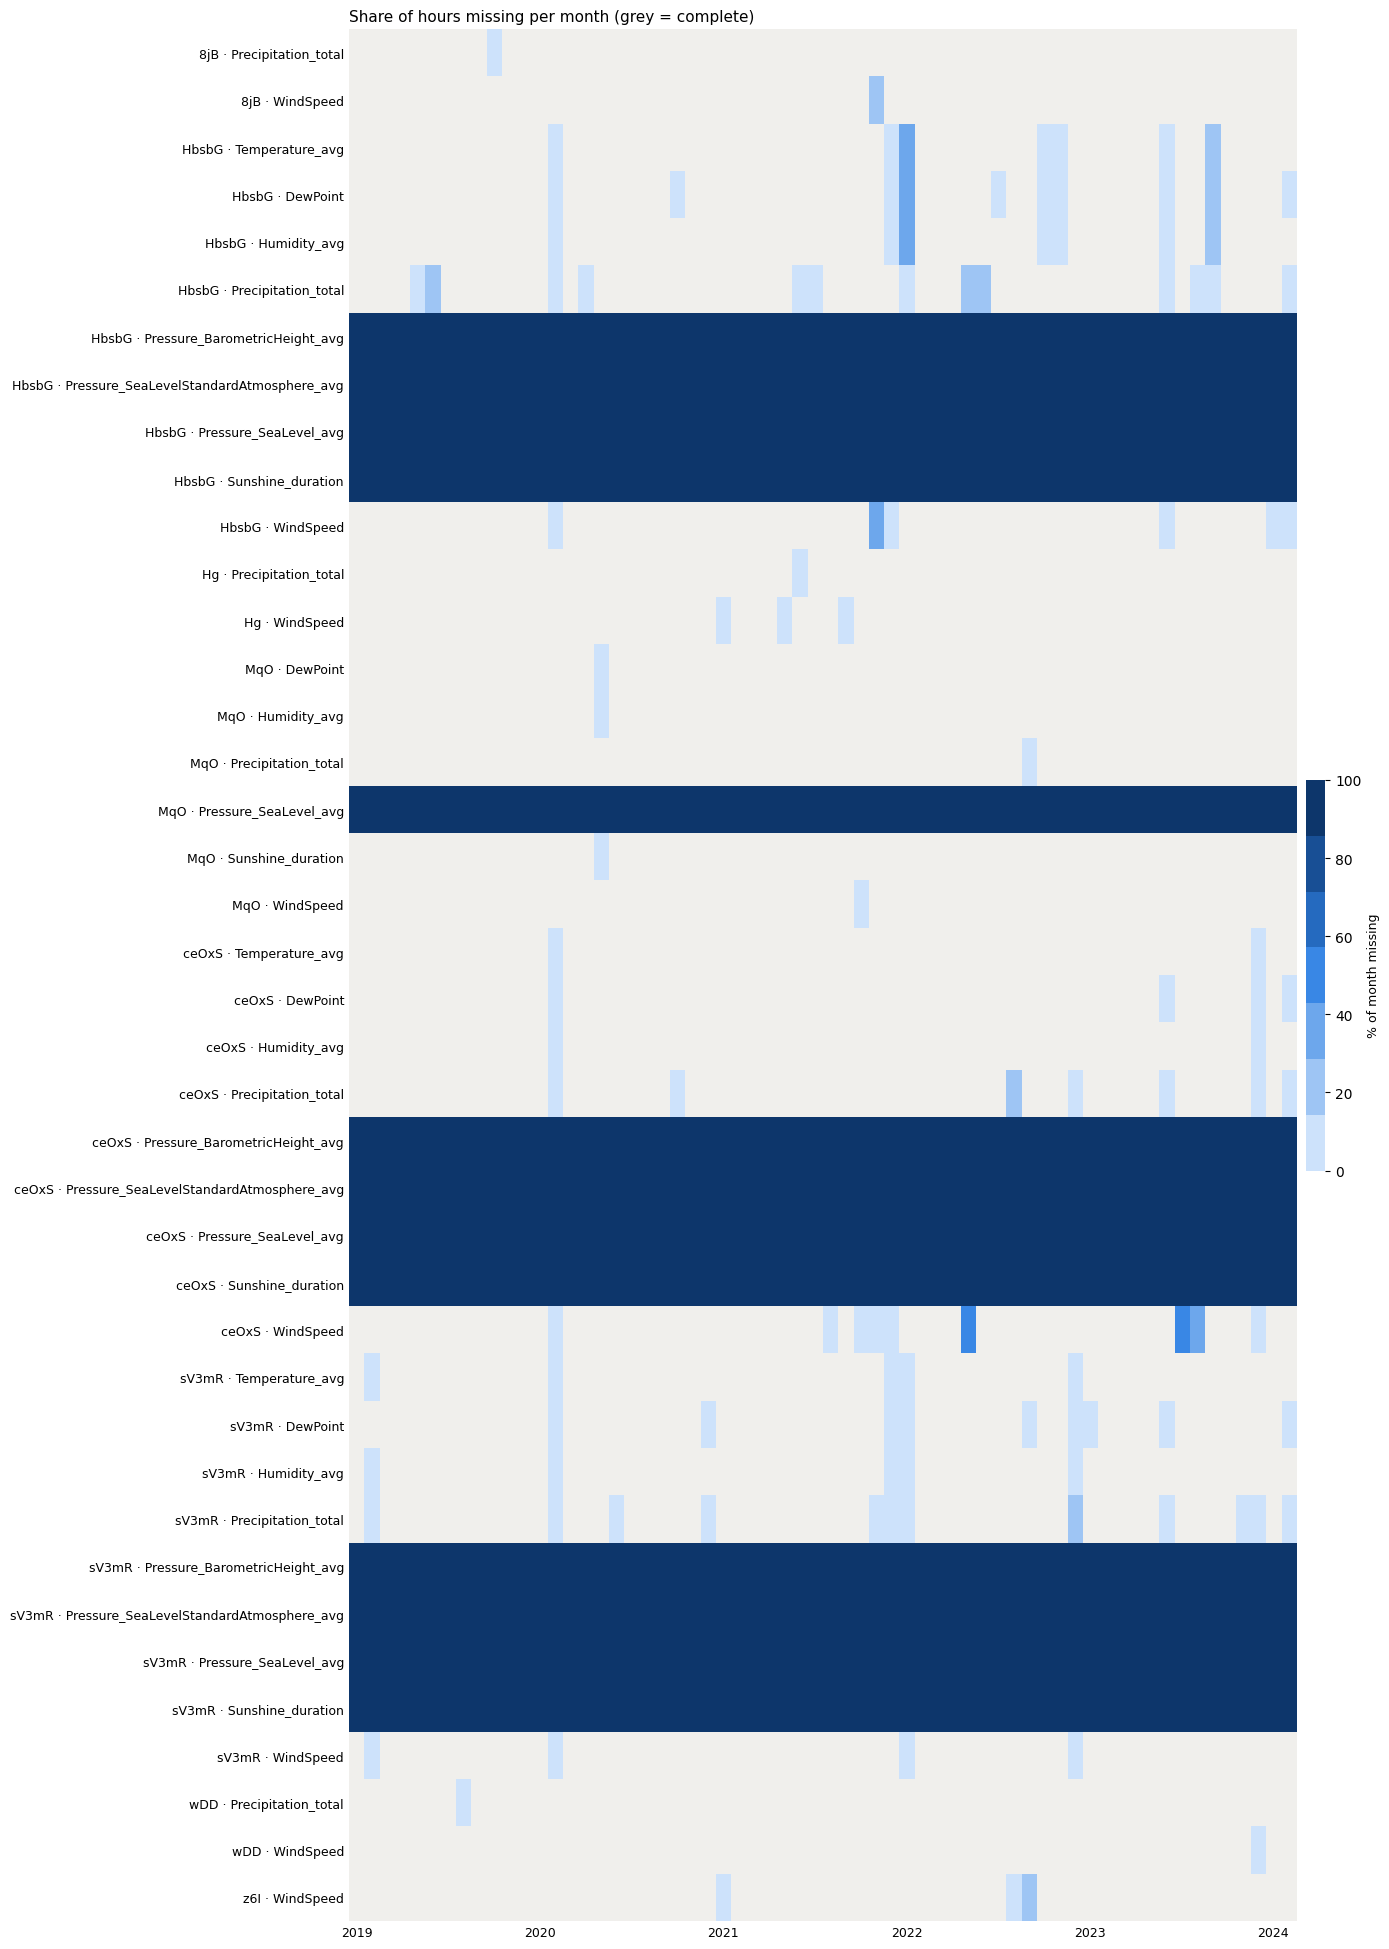

In [96]:

# 4) Hidden missingness: placeholders and flat-lined sensors -------------------
hidden = []
for sid, df in stations.items():
    for c in df.columns:
        s = df[c]
        n_sentinel = s.isin([-999, -9999, -99.9, 9999]).sum()
        longest_flat = 0
        if c not in NO_FLATLINE:
            v = s.dropna()
            if len(v):
                runs = v.ne(v.shift()).cumsum()
                longest_flat = int(runs.value_counts().max())
        if n_sentinel or longest_flat >= 24:
            hidden.append(dict(station=sid, variable=c, sentinel_values=n_sentinel,
                               longest_constant_run_h=longest_flat))
print("── Suspected hidden missingness (placeholders, ≥24 h constant) ──")
display(pd.DataFrame(hidden) if hidden else "None found")

# 5) Where in time: % missing per month, per station·variable -------------------
miss_rows = summary.index[summary.n_gaps > 0]
if len(miss_rows):
    monthly = pd.DataFrame({f"{s} · {v.replace('_hourly', '')}": stations[s][v].isna().resample("MS").mean() * 100
                            for s, v in miss_rows}).T
    cmap = ListedColormap(["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
    cmap.set_bad("#f0efec")
    data = monthly.where(monthly > 0)                       # 0% -> neutral background
    fig, ax = plt.subplots(figsize=(14, 0.45 * len(monthly) + 1.6))
    im = ax.imshow(data, aspect="auto", cmap=cmap, vmin=0, vmax=max(5, np.nanmax(data.values)),
                   interpolation="nearest")
    ax.set_yticks(range(len(monthly)), monthly.index, fontsize=9)
    ticks = [i for i, d in enumerate(monthly.columns) if d.month == 1]
    ax.set_xticks(ticks, [monthly.columns[i].year for i in ticks], fontsize=9)
    ax.set_title("Share of hours missing per month (grey = complete)", loc="left", fontsize=11)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.tick_params(length=0)
    cb = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
    cb.set_label("% of month missing", fontsize=9)
    cb.outline.set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values in any station.")

# Model Construction